# 🔬 `nb_06` — Unified Reduction Ladder Evaluation Suite & Multi-Model Comparison

> **Strict Evaluation & Comparative Analysis Notebook**  
> **Clean Architecture:** Zero training code. Uses `src.evaluation` (`EvaluationSuite`, `BenchmarkRegistry`, `EvaluationReporter`).  
> **Structure:**  
> - **1 Dedicated Cell per Model (M1 to M6):** Each model has its own cell with intelligent cached report detection and on-demand GPU inference.  
> - **Final Comparison Cell:** Dynamically auto-discovers all completed models, builds the consolidated comparison table, generates publication figures, and outputs LaTeX tables.

---

### 📊 Model Evaluation Taxonomy

| Model ID | Research Identifier | Paradigm / Checkpoint | Primary Probing Hypothesis |
|:---|:---|:---|:---|
| **M1** | Zero-Shot Baseline | `Qwen/Qwen2.5-Coder-1.5B-Instruct` | Zero-shot un-tuned degradation across ladder. |
| **M2** | Vanilla SFT (CoT) | `checkpoints/qlora_vanilla_adapter` | CoT boosts $L_2$–$L_5$ but drops $L_0$ canonical fluency. |
| **M3** | Contrastive SFT / DPO | `checkpoints/qlora_contrastive_adapter` | Explicit shortcut rejection unlearns naive templates. |
| **M4** | Standard GRPO | `checkpoints/standard_grpo_final` | Binary outcome RLVR improves fluency but overfits surface. |
| **M5** | AST-RL | `checkpoints/rlvr_ast_final` | Syntax-tree similarity prevents lexical variable overfitting. |
| **M6** | **Inv-GRPO (Ours)** | `checkpoints/inv_grpo_final` | Invariance-regularized paired RL resolves mimicry. |

### 🎯 Benchmark Pool (764 Held-Out Tasks across 7 Rungs)
- **$L_0$:** HumanEval Standard (164 tasks)
- **$L_1$–$L_5$:** EvoEval Subtle, ToolUse, Creative, Difficult, Combine (500 held-out tasks)
- **Ctrl:** LiveCodeBench Lite (100 tasks, temporal OOD control)


## ⚙️ Cell 01 — Environment Initialisation & Hardware Verification


In [1]:
import os
import sys
import json
from pathlib import Path
import datetime

# ── Detect Environment & Setup Repo ──────────────────────────────────────────
IS_KAGGLE = os.path.exists('/kaggle')

if IS_KAGGLE:
    print('⚡ Kaggle Environment Detected!')
    import subprocess
    # Install required dependencies quietly if not present
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'peft>=0.14.0', 'bitsandbytes>=0.45.0', 'accelerate>=1.2.0'])
    
    # Avoid drive letter issues on Linux by setting HF_HOME to writable working cache
    os.environ['HF_HOME'] = '/kaggle/working/hf_cache'
    os.environ['TRANSFORMERS_CACHE'] = '/kaggle/working/hf_cache'
    
    # Check where repository src is located
    if os.path.exists('/kaggle/working/reo/src'):
        REPO_ROOT = '/kaggle/working/reo'
    elif os.path.exists('/kaggle/working/src'):
        REPO_ROOT = '/kaggle/working'
    elif os.path.exists('./src'):
        REPO_ROOT = os.path.abspath('.')
    else:
        print('Cloning repository into /kaggle/working/reo...')
        subprocess.run(['git', 'clone', 'https://github.com/OmarAbdelhamidAly/diagnosing-resolving-code-slm-mimicry.git', '/kaggle/working/reo'])
        REPO_ROOT = '/kaggle/working/reo'
else:
    try:
        _nb_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        _nb_dir = os.path.abspath(os.getcwd())

    REPO_ROOT = _nb_dir if os.path.isfile(os.path.join(_nb_dir, 'requirements.txt')) \
        else os.path.abspath(os.path.join(_nb_dir, '..'))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print(f'Repo root    : {REPO_ROOT}')
print(f'Working dir  : {os.getcwd()}')

# ── Check GPU & PyTorch ──────────────────────────────────────────────────────
try:
    import torch
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_properties(0)
        print(f'GPU Node     : {gpu.name} ({gpu.total_memory / 1e9:.2f} GB VRAM)')
        print(f'CUDA Version : {torch.version.cuda}')
    else:
        print('GPU Node     : CPU-only mode (Evaluation will run in dry-run mode)')
    print(f'PyTorch      : {torch.__version__}')
except ImportError:
    print('PyTorch not installed.')

# ── Dynamic Path Resolvers (Kaggle & Local) ──────────────────────────────────
def resolve_data_dir() -> Path:
    '''Locate data/ladder directory locally or across Kaggle input datasets.'''
    local_path = Path(REPO_ROOT) / 'data' / 'ladder'
    if local_path.exists() and (local_path / 'L0_humaneval_standard.jsonl').exists():
        return local_path

    if os.path.exists('/kaggle/input'):
        for root, dirs, files in os.walk('/kaggle/input'):
            if 'L0_humaneval_standard.jsonl' in files:
                print(f'📁 Auto-detected Benchmark Ladder at: {root}')
                return Path(root)
    return local_path

def resolve_adapter_path(name: str) -> str:
    '''Locate LoRA adapter directory locally or across Kaggle input datasets.'''
    # 1. Local repo checkpoints
    local_path = Path(REPO_ROOT) / 'checkpoints' / name
    if local_path.exists() and (local_path / 'adapter_config.json').exists():
        return str(local_path)

    # 2. Search all Kaggle inputs dynamically
    if os.path.exists('/kaggle/input'):
        for root, dirs, files in os.walk('/kaggle/input'):
            if (os.path.basename(root) == name or name in root) and 'adapter_config.json' in files:
                print(f'🎯 Auto-detected checkpoint "{name}" at: {root}')
                return root

    return str(local_path)

# ── Import Evaluation Framework ──────────────────────────────────────────────
from src.evaluation import EvaluationSuite, BenchmarkRegistry, EvaluationReporter
from src.evaluation import metrics as eval_metrics
print('✅ src.evaluation framework loaded successfully.')

# ── Cache Validation Helper ──────────────────────────────────────────────────
from src.evaluation.suite import HARNESS_VERSION as _CURRENT_HARNESS_VERSION

def validate_report(report: dict, path: str = '') -> bool:
    '''Return True only if *report* was generated by the current harness.'''
    stored = report.get('harness_version', None)
    if stored != _CURRENT_HARNESS_VERSION:
        label = f' ({path})' if path else ''
        print(f'⚠️  [STALE CACHE]{label}')
        print(f'   Cached report was built with harness v{stored!r}.')
        print(f'   Current harness is v{_CURRENT_HARNESS_VERSION!r}. Discarding — will re-run on GPU.')
        return False
    return True

print(f'🔒 Harness version : {_CURRENT_HARNESS_VERSION}')

# ── Live Evaluation Snapshot, Auto-Backup & VRAM Safeguard ───────────────────
def snapshot_evaluation_progress(model_id: str, report: dict, output_dir: str = 'results'):
    '''Validates report, updates master CSV, packages zip backup, displays download link, and frees VRAM.'''
    import gc
    import torch
    import shutil
    import pandas as pd
    from pathlib import Path
    from IPython.display import display as ipy_display, FileLink, HTML
    
    if report is None:
        print(f'⚠️ No report found for {model_id}.')
        return

    l_reps = report.get('level_reports', {})
    print()
    print('=' * 70)
    print(f'📊 [EVALUATION SNAPSHOT] {model_id} (Harness v{report.get("harness_version", "N/A")})')
    print('=' * 70)
    
    rung_keys = ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'Ctrl']
    row_data = {'Model': model_id}
    
    for r in rung_keys:
        rep = l_reps.get(r, {})
        p1 = rep.get('pass_at_1', 0.0) if isinstance(rep, dict) else getattr(rep, 'pass_at_1', 0.0)
        passed = rep.get('passed_tasks', 0) if isinstance(rep, dict) else getattr(rep, 'passed_tasks', 0)
        total = rep.get('total_tasks', 0) if isinstance(rep, dict) else getattr(rep, 'total_tasks', 0)
        row_data[r] = f'{p1*100:.1f}%'
        status_icon = '🟢' if p1 >= 0.70 else ('🟡' if p1 >= 0.40 else '🔴')
        print(f'   {status_icon} {r:5s}: {p1*100:5.1f}%  ({passed}/{total} tasks)')
    
    auc = report.get('ladder_auc', 0.0) * 100
    slope = report.get('degradation_slope', 0.0)
    collapse = report.get('collapse_point', 'None')
    print(f'   📈 Ladder AUC      : {auc:.2f}%')
    print(f'   📉 Degrad. Slope   : {slope:.3f}')
    print(f'   ⚠️  Collapse Point  : {collapse}')
    print('=' * 70)
    
    # 1. Update master comparison CSV immediately
    csv_path = Path('results/master_comparison_table.csv')
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    row_data['Ladder AUC'] = f'{auc:.1f}%'
    row_data['Degrad. Slope'] = f'{slope:.3f}'
    row_data['Collapse Point'] = collapse
    
    df_new = pd.DataFrame([row_data]).set_index('Model')
    if csv_path.exists():
        try:
            df_existing = pd.read_csv(csv_path, index_col=0)
            df_combined = df_new.combine_first(df_existing)
            df_combined.update(df_new)
            df_combined.to_csv(csv_path)
            print(f'💾 Synchronized Master Table at: {csv_path}')
            display_cols = [c for c in rung_keys if c in df_combined.columns] + ['Ladder AUC', 'Degrad. Slope']
            print('\nCumulative Model Standings:')
            print(df_combined[display_cols].to_string())
        except Exception:
            df_new.to_csv(csv_path)
    else:
        df_new.to_csv(csv_path)
        print(f'💾 Created Master Table at: {csv_path}')
    
    # 2. Package downloadable zip backup after EVERY model cell
    results_dir = Path('results')
    if results_dir.exists():
        zip_base = '/kaggle/working/evaluation_results' if os.path.exists('/kaggle') else 'evaluation_results'
        shutil.make_archive(zip_base, 'zip', str(results_dir))
        zip_name = 'evaluation_results.zip'
        print(f'📦 [AUTO-BACKUP] Results successfully packaged into: {zip_base}.zip')
        try:
            target_zip = f'{zip_base}.zip' if os.path.exists('/kaggle') else zip_name
            ipy_display(FileLink(target_zip, result_html_prefix='📥 <b>Download Latest Results:</b> '))
        except Exception:
            pass
        
    # 3. Aggressive VRAM cleanup so next cell has 100% free GPU memory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f'🧹 VRAM Cleared: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved')
    print('=' * 70)
    print()


⚡ Kaggle Environment Detected!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 51.4 MB/s eta 0:00:00
Cloning repository into /kaggle/working/reo...


Cloning into '/kaggle/working/reo'...


Repo root    : /kaggle/working/reo
Working dir  : /kaggle/working/reo
GPU Node     : Tesla T4 (15.64 GB VRAM)
CUDA Version : 12.8
PyTorch      : 2.10.0+cu128
✅ src.evaluation framework loaded successfully.
🔒 Harness version : 1.2.0


## 📚 Cell 02 — Benchmark Registry & 764-Task Pool Integrity


In [2]:
registry = BenchmarkRegistry(data_dir=resolve_data_dir())
print(registry.integrity_report())
print()
counts = registry.task_counts()
print(f"Total tasks available : {sum(counts.values()):,} across {len(counts)} ladder rungs")
print(f"Rung breakdown        : {counts}")


📁 Auto-detected Benchmark Ladder at: /kaggle/input/datasets/omaraaly/slm-ladder-benchmarks/data/ladder
BenchmarkRegistry — Integrity Report
  L0        164 tasks   [OK]   L0_humaneval_standard.jsonl
  L1        100 tasks   [OK]   L1_evoeval_subtle.jsonl
  L2        100 tasks   [OK]   L2_evoeval_tooluse.jsonl
  L3        100 tasks   [OK]   L3_evoeval_creative.jsonl
  L4        100 tasks   [OK]   L4_evoeval_difficult.jsonl
  L5        100 tasks   [OK]   L5_evoeval_combine.jsonl
  Ctrl      100 tasks   [OK]   Ctrl_livecode_lite.jsonl

Total tasks available : 764 across 7 ladder rungs
Rung breakdown        : {'L0': 164, 'L1': 100, 'L2': 100, 'L3': 100, 'L4': 100, 'L5': 100, 'Ctrl': 100}


---
## 🔹 Cell 03 — Model M1: Zero-Shot Baseline (Qwen2.5-Coder-1.5B-Instruct)
Unmodified base model without adapters. Serves as reference anchor.


In [3]:
MODEL_ID = "M1_baseline"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = None
OUTPUT_DIR = "results/M1_baseline"
FORCE_RERUN = False

cached_report_paths = [
    Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json",
    Path("results/baseline/suite_report_baseline.json"),
]

report_m1 = None
for p in cached_report_paths:
    if p.exists() and not FORCE_RERUN:
        with open(p, "r", encoding="utf-8") as f:
            _candidate = json.load(f)
        if validate_report(_candidate, str(p)):
            report_m1 = _candidate
            print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {p}")
            break

if report_m1 is None:
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} on GPU...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=ADAPTER_PATH,
        output_dir=OUTPUT_DIR,
    )
    report_m1 = suite_report.to_dict()

snapshot_evaluation_progress(MODEL_ID, report_m1)


⚠️  [STALE CACHE] (results/baseline/suite_report_baseline.json)
   Cached report was built with harness vNone.
   Current harness is v'1.2.0'. Discarding — will re-run on GPU.
🚀 Running full ladder evaluation for M1_baseline on GPU...

[EvaluationSuite] Evaluating: M1_baseline
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : None (base model)
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  ✓ Pass@1=73.0%  Avg tokens≈128

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=75.0%  Avg tokens≈123

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=8.0%  Avg tokens≈108
  [SAVE] eval_report.json → results/M1_baseline/M1_baseline/eval_report.json

[EvaluationSuite] Done -> results/M1_baseline/M1_baseline/eval_report.json

📊 [EVALUATION SNAPSHOT] M1_baseline (Harness vN/A)
   🟢 L0   :  90.9%  (0/164 tasks)
   🟢 L1   :  87.0%  (0/100 tasks)
   🟡 L2   :  68.0%  (0/100 tasks)
   🟢 L3   :  76.0%  (0/100 tasks)
   🟢 L4   :  73.0%  (0/100 tasks)
   🟢 L5   :  75.0%  (0/100 tasks)
   🔴 Ctrl :   8.0%  (0/100 tasks)
   📈 Ladder AUC      : 77.39%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Created Master Table at: results/master_comparison_table.csv
📦 [AUTO-BACKUP] Results successfully packaged into: /kaggle/working/evaluation_results.zip


/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [4]:
# ── 🛡️ M1_baseline Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m1" in locals() and report_m1 is not None:
    print(f"✅ M1_baseline evaluation report confirmed in memory.")


✅ M1_baseline evaluation report confirmed in memory.


---
## 🔹 Cell 04 — Model M2: Vanilla SFT (CoT QLoRA Adapter)
Fine-tuned with Chain-of-Thought (SuperCorrect template). Exhibits high $L_2$–$L_5$ robustness but canonical $L_0$ trade-off.


In [5]:
MODEL_ID = "M2_vanilla_sft"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("qlora_vanilla_adapter")
chosen_adapter = ADAPTER_PATH
OUTPUT_DIR = "results/M2_vanilla_sft"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m2 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m2 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m2 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Train M2 via nb_04_qlora_training.ipynb or upload its adapter to Kaggle.")

snapshot_evaluation_progress(MODEL_ID, report_m2)


🎯 Auto-detected checkpoint "qlora_vanilla_adapter" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/qlora_vanilla_adapter
✅ Loaded cached evaluation for M2_vanilla_sft from: results/M2_vanilla_sft/M2_vanilla_sft/eval_report.json

📊 [EVALUATION SNAPSHOT] M2_vanilla_sft (Harness v1.1.0)
   🟡 L0   :  64.6%  (0/164 tasks)
   🟡 L1   :  59.0%  (0/100 tasks)
   🟢 L2   :  96.0%  (0/100 tasks)
   🟢 L3   :  95.0%  (0/100 tasks)
   🟢 L4   :  94.0%  (0/100 tasks)
   🟢 L5   :  92.0%  (0/100 tasks)
   🔴 Ctrl :   0.0%  (0/100 tasks)
   📈 Ladder AUC      : 84.46%
   📉 Degrad. Slope   : 0.069
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                   L0     L1     L2     L3     L4     L5  Ctrl Ladder AUC Degrad. Slope
Model                                                                                  
M1_baseline     90.9%  87.0%  68.0%  76.0%  73.0%  75.0%  8.0%      77.4%        

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [6]:
# ── 🛡️ M2_vanilla_sft Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m2" in locals() and report_m2 is not None:
    print(f"✅ M2_vanilla_sft evaluation report confirmed in memory.")


✅ M2_vanilla_sft evaluation report confirmed in memory.


---
## 🔹 Cell 05 — Model M3: Contrastive SFT / DPO (Arm 2)
Trained on paired contrastive preference data $(x, y^+, y^-)$ to reject memorized shortcuts.


In [7]:
MODEL_ID = "M3_contrastive_dpo"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("qlora_contrastive_adapter")
chosen_adapter = ADAPTER_PATH
OUTPUT_DIR = "results/M3_contrastive_dpo"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m3 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m3 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m3 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Execute Arm 2 training sweep (arm_02_contrastive_sft.ipynb) to evaluate M3.")

snapshot_evaluation_progress(MODEL_ID, report_m3)


🎯 Auto-detected checkpoint "qlora_contrastive_adapter" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/qlora_contrastive_adapter
🚀 Running full ladder evaluation for M3_contrastive_dpo with adapter /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/qlora_contrastive_adapter...

[EvaluationSuite] Evaluating: M3_contrastive_dpo
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/qlora_contrastive_adapter
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL] Loading LoRA adapter weights from '/kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/qlora_contrastive_adapter'...
[MODEL] Model successfully loaded and ready for inference.

[LEVEL] L0  (164 tasks | batch_size=16)


  ✓ Pass@1=70.1%  Avg tokens≈66

[LEVEL] L1  (100 tasks | batch_size=16)


  ✓ Pass@1=71.0%  Avg tokens≈62

[LEVEL] L2  (100 tasks | batch_size=16)


...

  ✓ Pass@1=51.0%  Avg tokens≈128

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=55.0%  Avg tokens≈145

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=4.0%  Avg tokens≈89
  [SAVE] eval_report.json → results/M3_contrastive_dpo/M3_contrastive_dpo/eval_report.json

[EvaluationSuite] Done -> results/M3_contrastive_dpo/M3_contrastive_dpo/eval_report.json

📊 [EVALUATION SNAPSHOT] M3_contrastive_dpo (Harness vN/A)
   🟢 L0   :  70.1%  (0/164 tasks)
   🟢 L1   :  71.0%  (0/100 tasks)
   🔴 L2   :  32.0%  (0/100 tasks)
   🟡 L3   :  42.0%  (0/100 tasks)
   🟡 L4   :  51.0%  (0/100 tasks)
   🟡 L5   :  55.0%  (0/100 tasks)
   🔴 Ctrl :   4.0%  (0/100 tasks)
   📈 Ladder AUC      : 51.71%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : L2
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                       L0     L1     L2     L3     L4     L5  Ctrl Ladder AUC Degrad. Slope
Model                                                                                      
M1_baseline         90.9%  87.0%  68.0%  76.0%  73.0%  75.0%  8.0%      77.4%           0.0
M2_vanilla_sft      64.6%  59.0

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [8]:
# ── 🛡️ M3_contrastive_dpo Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m3" in locals() and report_m3 is not None:
    print(f"✅ M3_contrastive_dpo evaluation report confirmed in memory.")


✅ M3_contrastive_dpo evaluation report confirmed in memory.


---
## 🔹 Cell 06 — Model M4: Standard GRPO (Arm 0 — RLVR Baseline)
Outcome-only binary RLVR without invariance regularization. Ablation control baseline.


In [9]:
MODEL_ID = "M4_standard_grpo"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("standard_grpo_final")
chosen_adapter = ADAPTER_PATH
OUTPUT_DIR = "results/M4_standard_grpo"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m4 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m4 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m4 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Execute Standard GRPO training (arm_01b_standard_grpo.ipynb) to evaluate M4.")

snapshot_evaluation_progress(MODEL_ID, report_m4)


🎯 Auto-detected checkpoint "standard_grpo_final" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/standard_grpo_final
🚀 Running full ladder evaluation for M4_standard_grpo with adapter /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/standard_grpo_final...

[EvaluationSuite] Evaluating: M4_standard_grpo
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/standard_grpo_final
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL] Loading LoRA adapter weights from '/kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/standard_grpo_final'...
[MODEL] Model successfully loaded and ready for inference.

[LEVEL] L0  (164 tasks | batch_size=16)


  ✓ Pass@1=98.2%  Avg tokens≈23

[LEVEL] L1  (100 tasks | batch_size=16)


  ✓ Pass@1=98.0%  Avg tokens≈24

[LEVEL] L2  (100 tasks | batch_size=16)


...

  ✓ Pass@1=98.0%  Avg tokens≈42

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=95.0%  Avg tokens≈45

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=6.0%  Avg tokens≈43
  [SAVE] eval_report.json → results/M4_standard_grpo/M4_standard_grpo/eval_report.json

[EvaluationSuite] Done -> results/M4_standard_grpo/M4_standard_grpo/eval_report.json

📊 [EVALUATION SNAPSHOT] M4_standard_grpo (Harness vN/A)
   🟢 L0   :  98.2%  (0/164 tasks)
   🟢 L1   :  98.0%  (0/100 tasks)
   🟢 L2   :  98.0%  (0/100 tasks)
   🟢 L3   :  99.0%  (0/100 tasks)
   🟢 L4   :  98.0%  (0/100 tasks)
   🟢 L5   :  95.0%  (0/100 tasks)
   🔴 Ctrl :   6.0%  (0/100 tasks)
   📈 Ladder AUC      : 97.92%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                       L0     L1     L2     L3     L4     L5  Ctrl Ladder AUC Degrad. Slope
Model                                                                                      
M1_baseline         90.9%  87.0%  68.0%  76.0%  73.0%  75.0%  8.0%      77.4%           0.0
M2_vanilla_sft      6

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [10]:
# ── 🛡️ M4_standard_grpo Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m4" in locals() and report_m4 is not None:
    print(f"✅ M4_standard_grpo evaluation report confirmed in memory.")


✅ M4_standard_grpo evaluation report confirmed in memory.


---
## 🔹 Cell 07 — Model M5: AST-Guided Policy Optimization (Arm 3)
Guided by Abstract Syntax Tree control-flow similarity (TreeDiff / VeriSeek) to eliminate lexical overfitting.


In [11]:
MODEL_ID = "M5_ast_rl"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("rlvr_ast_final")
chosen_adapter = ADAPTER_PATH
OUTPUT_DIR = "results/M5_ast_rl"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m5 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m5 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m5 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Execute AST-RL training (arm_03_ast_rl.ipynb) to evaluate M5.")

snapshot_evaluation_progress(MODEL_ID, report_m5)


🎯 Auto-detected checkpoint "rlvr_ast_final" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/rlvr_ast_final
🚀 Running full ladder evaluation for M5_ast_rl with adapter /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/rlvr_ast_final...

[EvaluationSuite] Evaluating: M5_ast_rl
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/rlvr_ast_final
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL] Loading LoRA adapter weights from '/kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/rlvr_ast_final'...
[MODEL] Model successfully loaded and ready for inference.

[LEVEL] L0  (164 tasks | batch_size=16)


  ✓ Pass@1=99.4%  Avg tokens≈51

[LEVEL] L1  (100 tasks | batch_size=16)


  ✓ Pass@1=98.0%  Avg tokens≈53

[LEVEL] L2  (100 tasks | batch_size=16)


...

  ✓ Pass@1=96.0%  Avg tokens≈76

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=93.0%  Avg tokens≈83

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=10.0%  Avg tokens≈91
  [SAVE] eval_report.json → results/M5_ast_rl/M5_ast_rl/eval_report.json

[EvaluationSuite] Done -> results/M5_ast_rl/M5_ast_rl/eval_report.json

📊 [EVALUATION SNAPSHOT] M5_ast_rl (Harness vN/A)
   🟢 L0   :  99.4%  (0/164 tasks)
   🟢 L1   :  98.0%  (0/100 tasks)
   🟢 L2   :  91.0%  (0/100 tasks)
   🟢 L3   : 100.0%  (0/100 tasks)
   🟢 L4   :  96.0%  (0/100 tasks)
   🟢 L5   :  93.0%  (0/100 tasks)
   🔴 Ctrl :  10.0%  (0/100 tasks)
   📈 Ladder AUC      : 96.24%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                       L0     L1     L2      L3     L4     L5   Ctrl Ladder AUC Degrad. Slope
Model                                                                                        
M1_baseline         90.9%  87.0%  68.0%   76.0%  73.0%  75.0%   8.0%      77.4%           0.0
M2_vanilla_sft      64.6%  59.0%  96.0%   95.0%  

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [12]:
# ── 🛡️ M5_ast_rl Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m5" in locals() and report_m5 is not None:
    print(f"✅ M5_ast_rl evaluation report confirmed in memory.")


✅ M5_ast_rl evaluation report confirmed in memory.


---
## 🔹 Cell 08 — Model M6: Inv-GRPO (Arm 1 — Primary Contribution)
Invariance-Regularized Paired GRPO. Resolves shortcut mimicry and preserves canonical precision.


In [13]:
MODEL_ID = "M6_inv_grpo"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("inv_grpo_final")
alt_adapter = resolve_adapter_path("rlvr_inv_grpo_final")
chosen_adapter = ADAPTER_PATH if (os.path.exists(ADAPTER_PATH) and (Path(ADAPTER_PATH) / "adapter_config.json").exists()) else alt_adapter
OUTPUT_DIR = "results/M6_inv_grpo"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m6 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m6 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m6 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Execute Arm 1 full training (arm_01_inv_grpo.ipynb) to generate M6.")

snapshot_evaluation_progress(MODEL_ID, report_m6)


🎯 Auto-detected checkpoint "inv_grpo_final" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/inv_grpo_final
🚀 Running full ladder evaluation for M6_inv_grpo with adapter /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/inv_grpo_final...

[EvaluationSuite] Evaluating: M6_inv_grpo
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/inv_grpo_final
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL] Loading LoRA adapter weights from '/kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/inv_grpo_final'...
[MODEL] Model successfully loaded and ready for inference.

[LEVEL] L0  (164 tasks | batch_size=16)


  ✓ Pass@1=90.9%  Avg tokens≈91

[LEVEL] L1  (100 tasks | batch_size=16)


  ✓ Pass@1=86.0%  Avg tokens≈91

[LEVEL] L2  (100 tasks | batch_size=16)


...

  ✓ Pass@1=76.0%  Avg tokens≈126

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=76.0%  Avg tokens≈124

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=9.0%  Avg tokens≈99
  [SAVE] eval_report.json → results/M6_inv_grpo/M6_inv_grpo/eval_report.json

[EvaluationSuite] Done -> results/M6_inv_grpo/M6_inv_grpo/eval_report.json

📊 [EVALUATION SNAPSHOT] M6_inv_grpo (Harness vN/A)
   🟢 L0   :  90.9%  (0/164 tasks)
   🟢 L1   :  86.0%  (0/100 tasks)
   🟡 L2   :  69.0%  (0/100 tasks)
   🟢 L3   :  74.0%  (0/100 tasks)
   🟢 L4   :  76.0%  (0/100 tasks)
   🟢 L5   :  76.0%  (0/100 tasks)
   🔴 Ctrl :   9.0%  (0/100 tasks)
   📈 Ladder AUC      : 77.69%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                       L0     L1     L2      L3     L4     L5   Ctrl Ladder AUC Degrad. Slope
Model                                                                                        
M1_baseline         90.9%  87.0%  68.0%   76.0%  73.0%  75.0%   8.0%      77.4%           0.0
M2_vanilla_sft      64.6%  59.0%  96.0% 

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [14]:
# ── 🛡️ M6_inv_grpo Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m6" in locals() and report_m6 is not None:
    print(f"✅ M6_inv_grpo evaluation report confirmed in memory.")


✅ M6_inv_grpo evaluation report confirmed in memory.


---
## 🧪 Cell 08 — Arm 4: Step-RLVR Evaluation (M7: Stepwise Contract Verifier)
Evaluates the fine-grained intermediate execution verification model (Arm 4).


In [15]:
MODEL_ID = "M7_step_rlvr"
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
ADAPTER_PATH = resolve_adapter_path("step_rlvr_final")
alt_adapter = resolve_adapter_path("rlvr_step_final")
chosen_adapter = ADAPTER_PATH if (os.path.exists(ADAPTER_PATH) and (Path(ADAPTER_PATH) / "adapter_config.json").exists()) else alt_adapter
OUTPUT_DIR = "results/M7_step_rlvr"
FORCE_RERUN = False

report_path = Path(OUTPUT_DIR) / MODEL_ID / "eval_report.json"
report_m7 = None

if report_path.exists() and not FORCE_RERUN:
    with open(report_path, "r", encoding="utf-8") as f:
        report_m7 = json.load(f)
    print(f"✅ Loaded cached evaluation for {MODEL_ID} from: {report_path}")
elif os.path.exists(chosen_adapter) and (Path(chosen_adapter) / "adapter_config.json").exists():
    print(f"🚀 Running full ladder evaluation for {MODEL_ID} with adapter {chosen_adapter}...")
    suite = EvaluationSuite(registry=registry, evaluate_pass5=False, timeout_seconds=8.0)
    suite_report = suite.evaluate_model(
        model_id=MODEL_ID,
        model_name_or_path=BASE_MODEL,
        adapter_path=chosen_adapter,
        output_dir=OUTPUT_DIR,
    )
    report_m7 = suite_report.to_dict()
else:
    print(f"ℹ️ [PENDING] Checkpoint not found at: {chosen_adapter}")
    print("   Execute Arm 4 full training (arm_04_step_rlvr.ipynb) to generate M7.")

snapshot_evaluation_progress(MODEL_ID, report_m7)


🎯 Auto-detected checkpoint "step_rlvr_final" at: /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/step_rlvr_final
🚀 Running full ladder evaluation for M7_step_rlvr with adapter /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/step_rlvr_final...

[EvaluationSuite] Evaluating: M7_step_rlvr
  Base model       : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Adapter          : /kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/step_rlvr_final
  Batch size       : 16
  Max new tokens   : 512
  Max tasks/level  : All
  Pass@5           : False

[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: /kaggle/working/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL] Loading LoRA adapter weights from '/kaggle/input/datasets/omaraaly/slm-checkpoints/checkpoints/step_rlvr_final'...
[MODEL] Model successfully loaded and ready for inference.

[LEVEL] L0  (164 tasks | batch_size=16)


  ✓ Pass@1=98.8%  Avg tokens≈42

[LEVEL] L1  (100 tasks | batch_size=16)


  ✓ Pass@1=99.0%  Avg tokens≈40

[LEVEL] L2  (100 tasks | batch_size=16)


...

  ✓ Pass@1=97.0%  Avg tokens≈59

[LEVEL] L5  (100 tasks | batch_size=16)


  ✓ Pass@1=95.0%  Avg tokens≈62

[LEVEL] Ctrl  (100 tasks | batch_size=16)


  ✓ Pass@1=7.0%  Avg tokens≈74
  [SAVE] eval_report.json → results/M7_step_rlvr/M7_step_rlvr/eval_report.json

[EvaluationSuite] Done -> results/M7_step_rlvr/M7_step_rlvr/eval_report.json

📊 [EVALUATION SNAPSHOT] M7_step_rlvr (Harness vN/A)
   🟢 L0   :  98.8%  (0/164 tasks)
   🟢 L1   :  99.0%  (0/100 tasks)
   🟢 L2   :  96.0%  (0/100 tasks)
   🟢 L3   : 100.0%  (0/100 tasks)
   🟢 L4   :  97.0%  (0/100 tasks)
   🟢 L5   :  95.0%  (0/100 tasks)
   🔴 Ctrl :   7.0%  (0/100 tasks)
   📈 Ladder AUC      : 97.78%
   📉 Degrad. Slope   : 0.000
   ⚠️  Collapse Point  : None (Maintained ≥50%)
💾 Synchronized Master Table at: results/master_comparison_table.csv

Cumulative Model Standings:
                       L0     L1     L2      L3     L4     L5   Ctrl Ladder AUC Degrad. Slope
Model                                                                                        
M1_baseline         90.9%  87.0%  68.0%   76.0%  73.0%  75.0%   8.0%      77.4%           0.0
M2_vanilla_sft      64.6%  59.0%  9

/kaggle/working/evaluation_results.zip

🧹 VRAM Cleared: 0.01 GB allocated, 0.49 GB reserved



In [16]:
# ── 🛡️ M7_step_rlvr Standings Confirmation ──
# Note: snapshot_evaluation_progress is already called automatically above.
# Running this cell confirms current cumulative standings and frees VRAM.
if "report_m7" in locals() and report_m7 is not None:
    print(f"✅ M7_step_rlvr evaluation report confirmed in memory.")


✅ M7_step_rlvr evaluation report confirmed in memory.


---
# 🏆 Cell 09 — Final Master Comparison & Publication Deliverables
### Reads all completed models, builds comparison table, renders figures, and exports LaTeX.


🏆 EVALUATION SUITE: DISCOVERED 7 COMPLETED MODELS
   1. M1_baseline            -> Ladder AUC: 77.39%
   2. M2_vanilla_sft         -> Ladder AUC: 84.46%
   3. M3_contrastive_dpo     -> Ladder AUC: 51.71%
   4. M4_standard_grpo       -> Ladder AUC: 97.92%
   5. M5_ast_rl              -> Ladder AUC: 96.24%
   6. M6_inv_grpo            -> Ladder AUC: 77.69%
   7. M7_step_rlvr           -> Ladder AUC: 97.78%

📊 MASTER COMPARISON TABLE (All Completed Models × All Metrics):


,L0,L1,L2,L3,L4,L5,Ctrl (OOD),Ladder AUC,Degrad. Slope,Collapse Point,Consistency Δ,Overthinking Tax,Rel. Gain vs M1
Model,,,,,,,,,,,,,
M1_baseline,90.9%,87.0%,68.0%,76.0%,73.0%,75.0%,8.0%,77.4%,-0.032,None (Maintained ≥50%),19.0%,0.635,+0.0%
M2_vanilla_sft,64.6%,59.0%,96.0%,95.0%,94.0%,92.0%,N/A,84.5%,+0.069,None (Maintained ≥50%),37.0%,2.311,+7.1%
M3_contrastive_dpo,70.1%,71.0%,32.0%,42.0%,51.0%,55.0%,4.0%,51.7%,-0.036,L2,39.0%,0.529,-25.7%
M4_standard_grpo,98.2%,98.0%,98.0%,99.0%,98.0%,95.0%,6.0%,97.9%,-0.004,None (Maintained ≥50%),0.0%,2.724,+20.5%
M5_ast_rl,99.4%,98.0%,91.0%,100.0%,96.0%,93.0%,10.0%,96.2%,-0.008,None (Maintained ≥50%),7.0%,1.318,+18.9%
M6_inv_grpo,90.9%,86.0%,69.0%,74.0%,76.0%,76.0%,9.0%,77.7%,-0.028,None (Maintained ≥50%),17.0%,0.647,+0.3%
M7_step_rlvr,98.8%,99.0%,96.0%,100.0%,97.0%,95.0%,7.0%,97.8%,-0.006,None (Maintained ≥50%),3.0%,1.774,+20.4%



💾 Saved Table to: results/master_comparison_table.csv
[PLOT] Saved -> results/figures/fig1_degradation_curves.png
[PLOT] Saved -> results/figures/fig3_grouped_bars.png
[PLOT] Saved -> results/figures/fig4_metric_heatmap.png

📈 1. Degradation Curves across Transformation Spectrum:


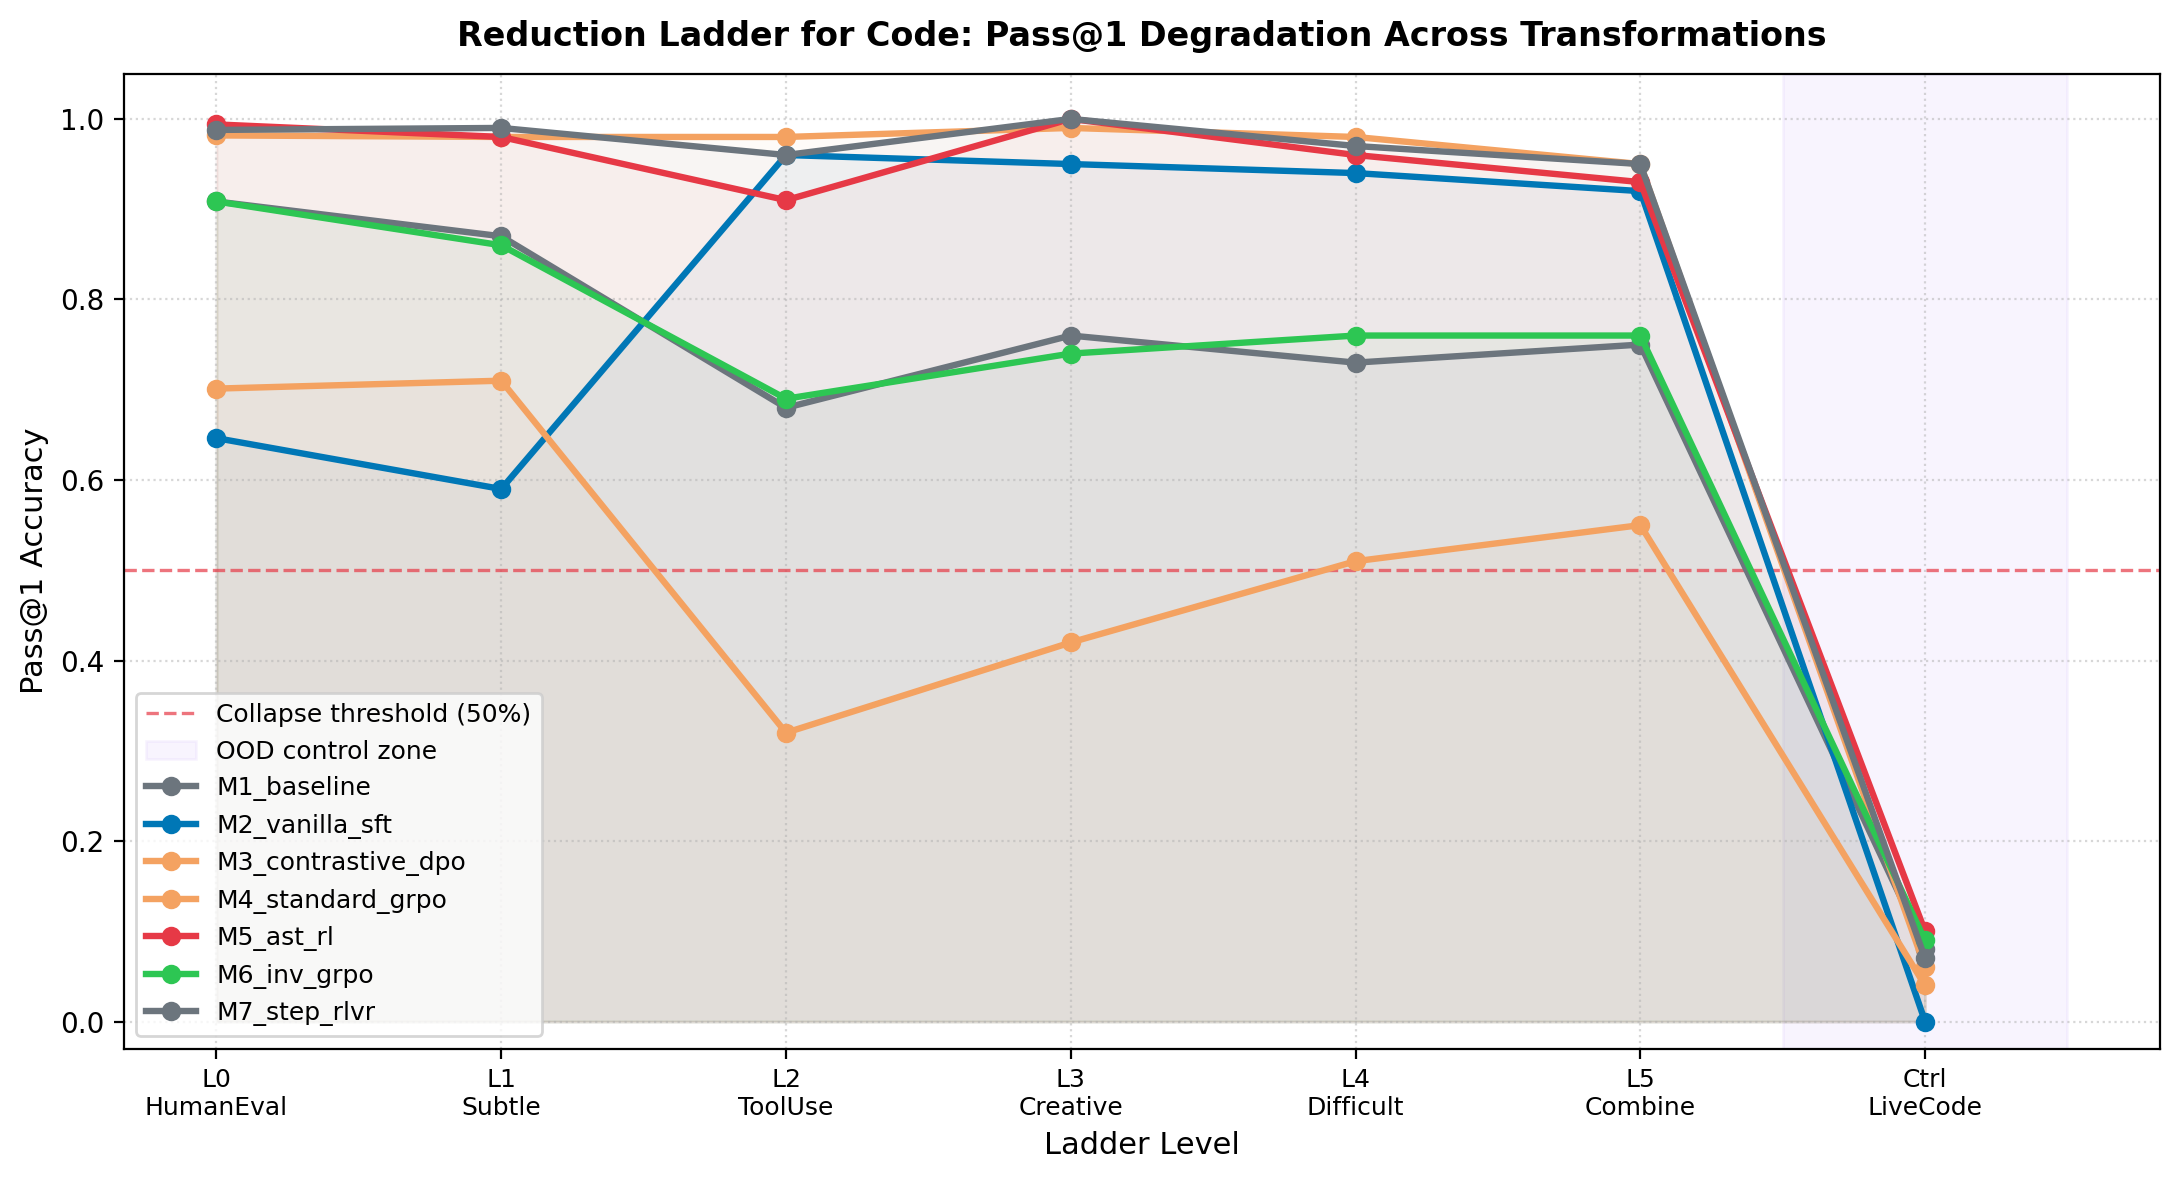


📊 2. Grouped Accuracy per Level:


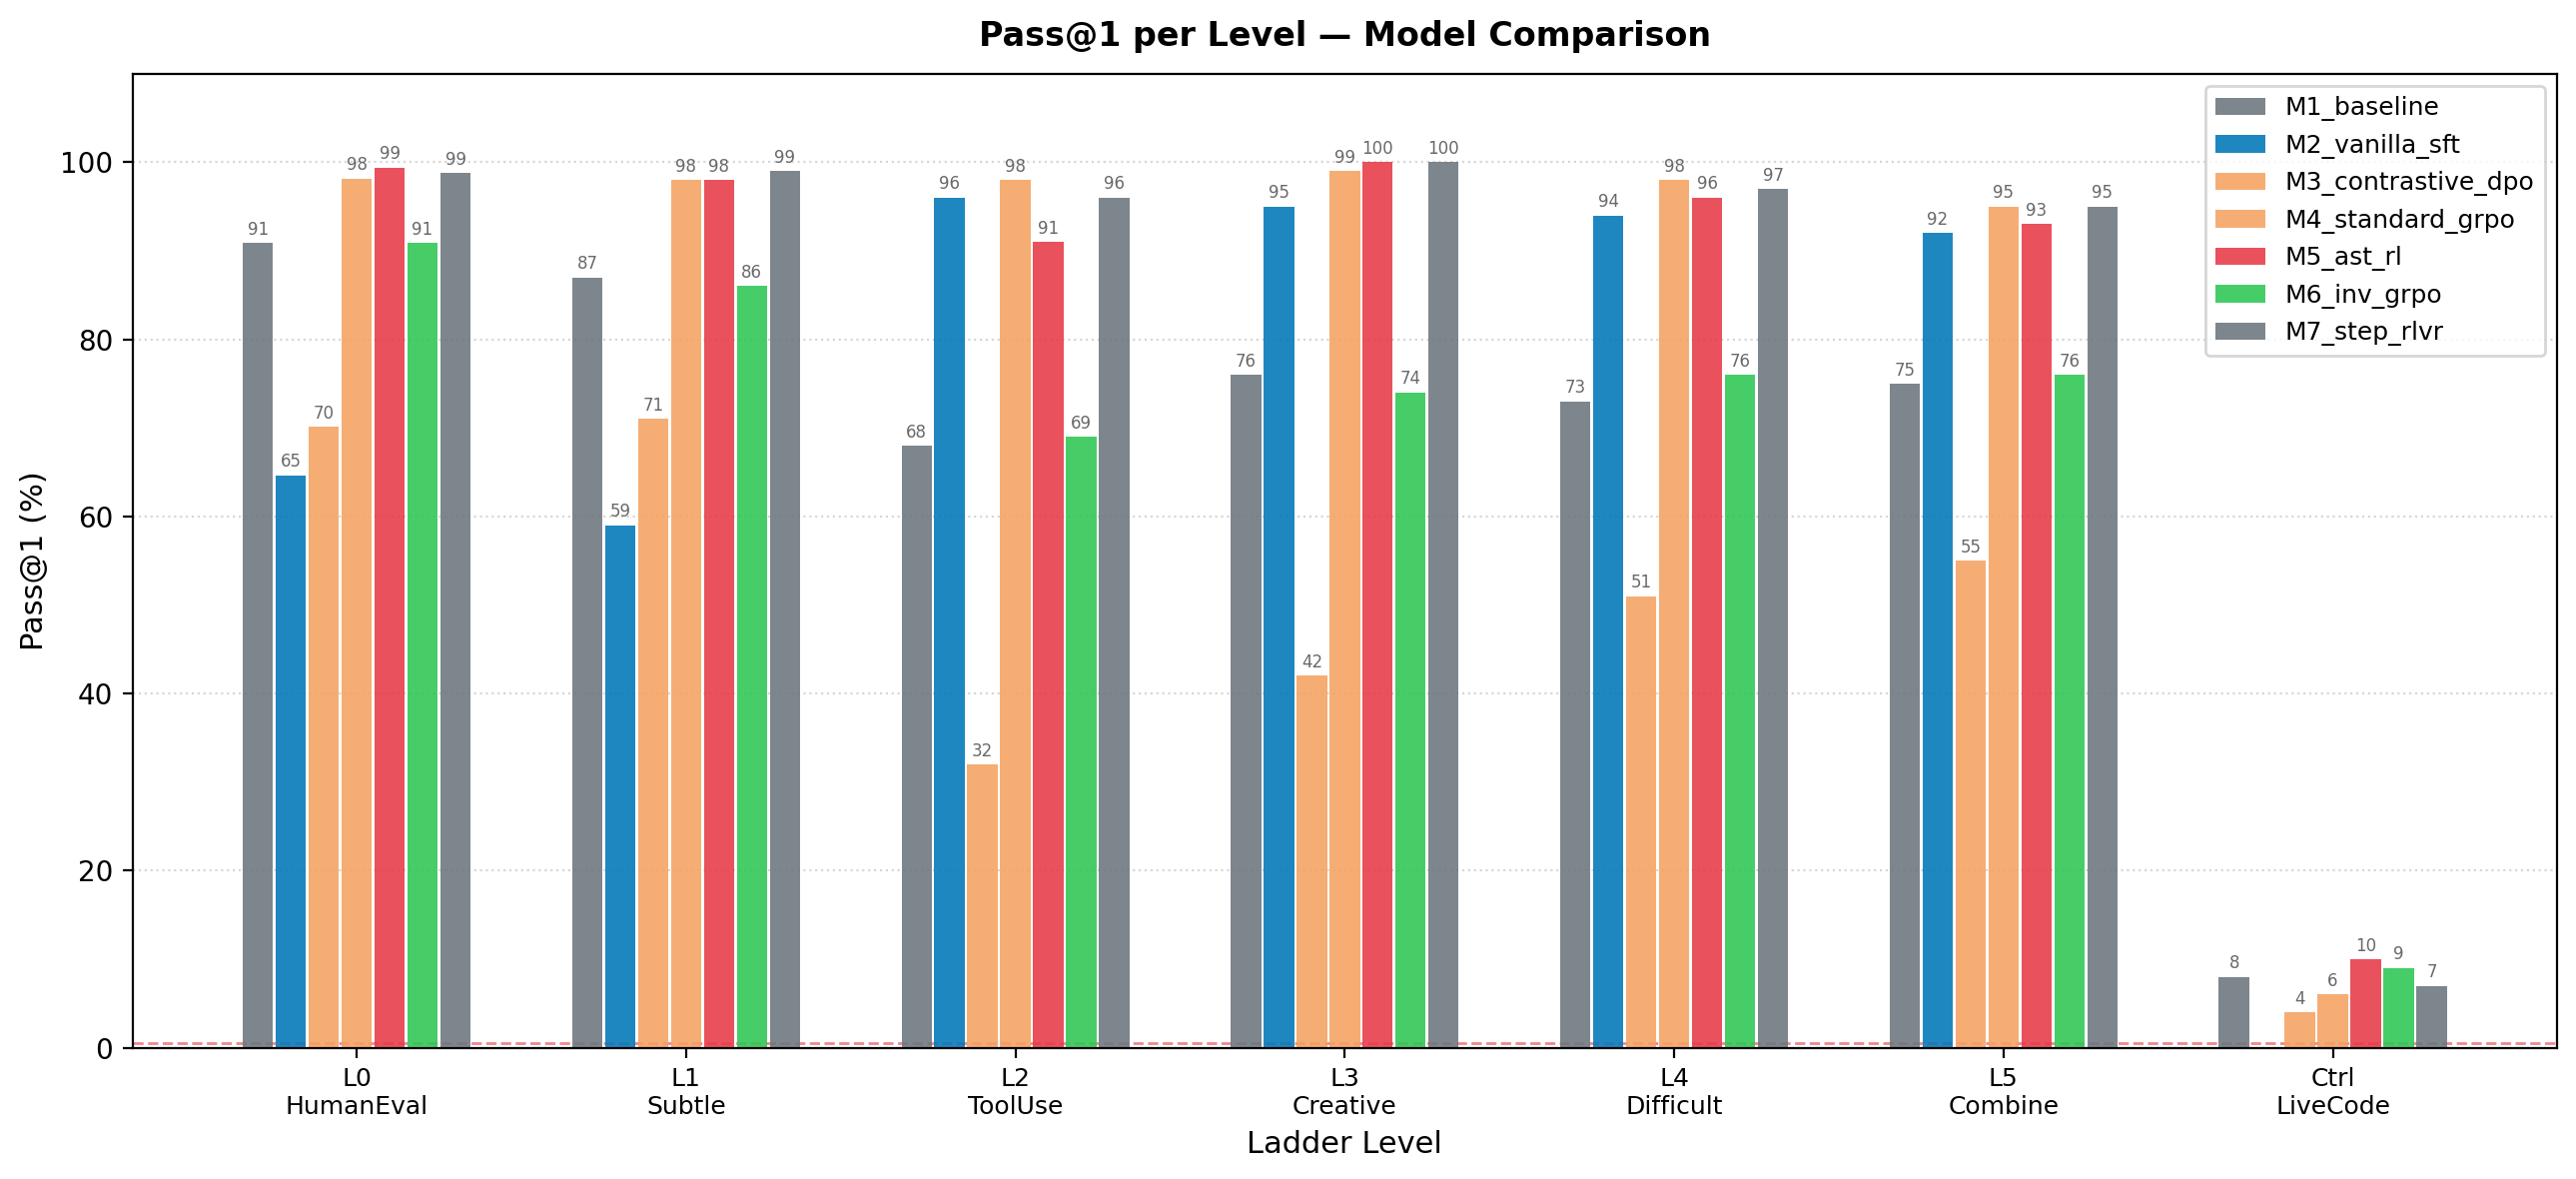


🌡️ 3. Full Metrics Heatmap:


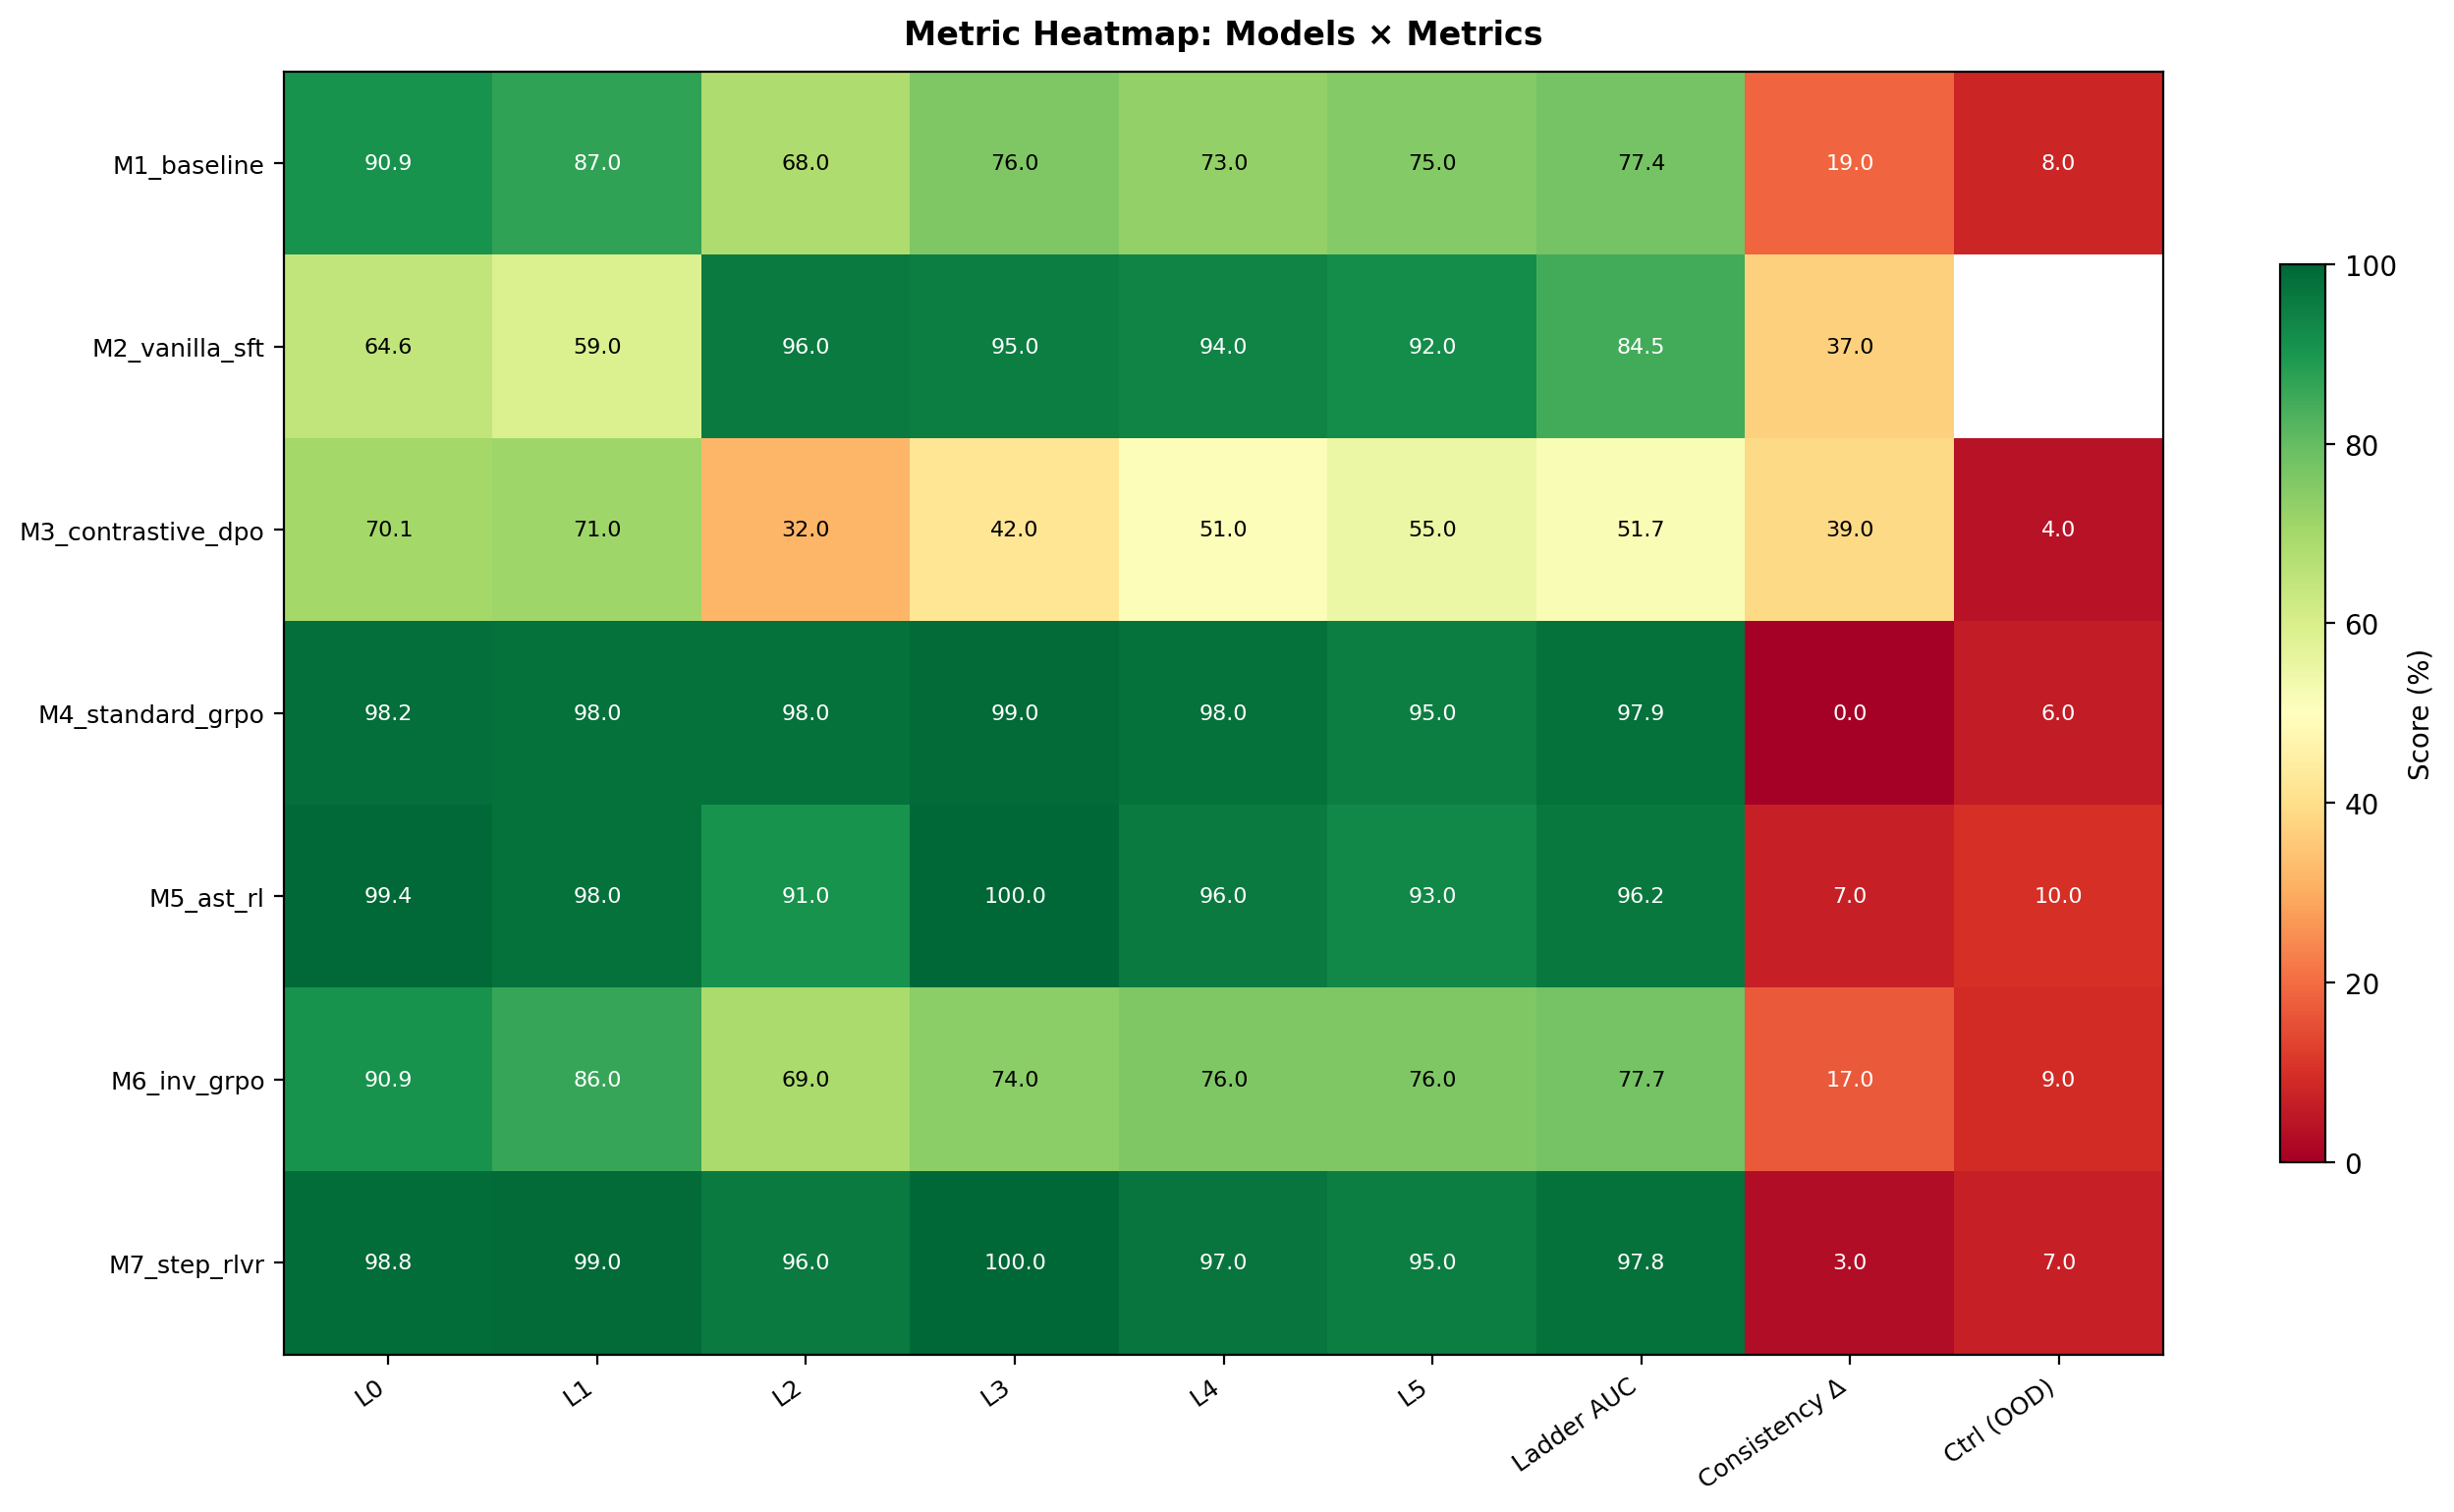

[PLOT] Saved -> results/figures/fig2_radar_chart.png

🎯 4. Multi-Axis Radar Fingerprint:


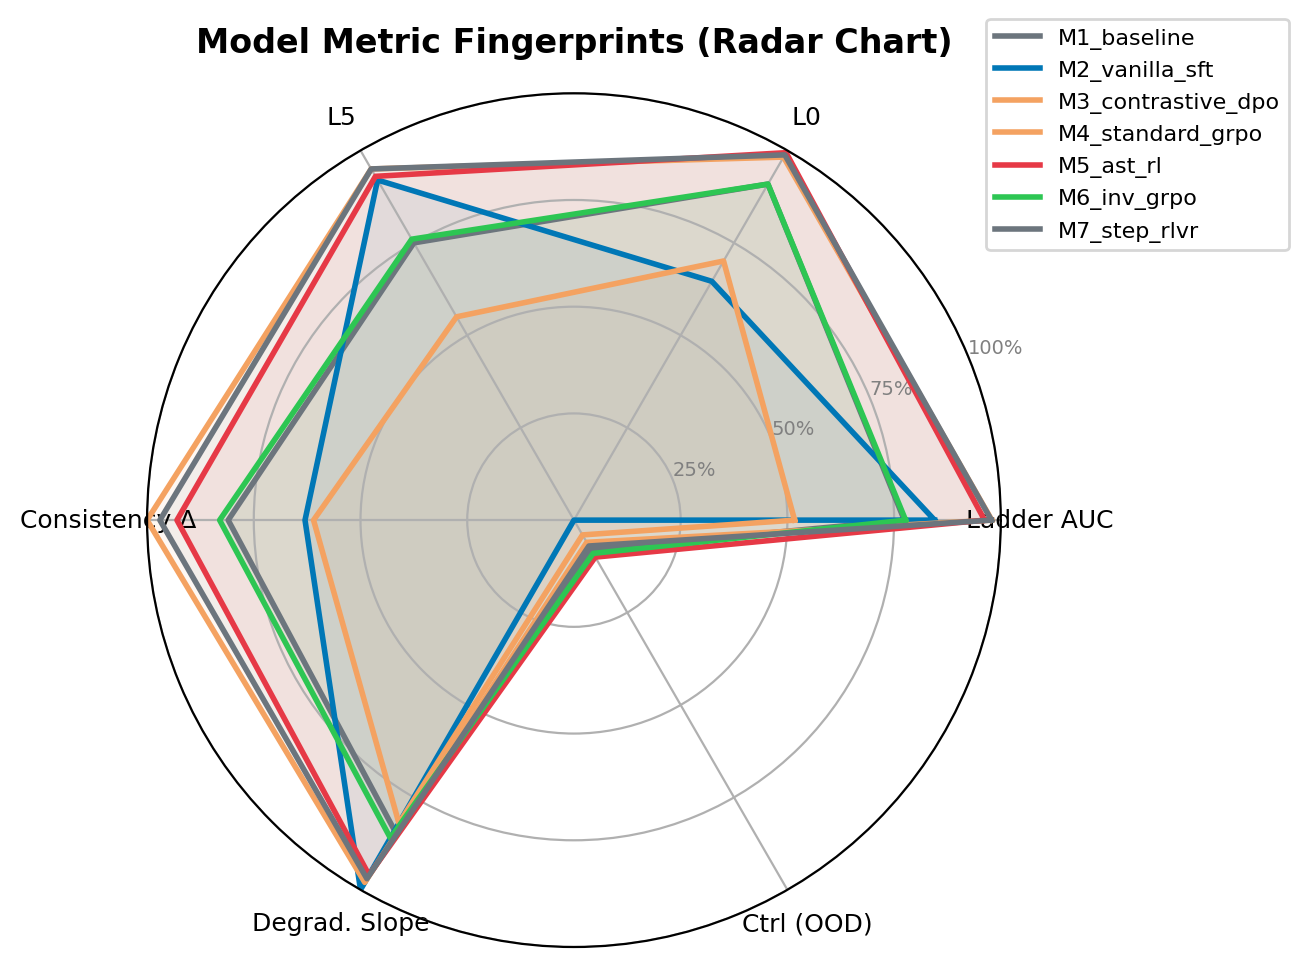


📄 PUBLICATION LATEX TABLE (Ready to copy into week_report.tex):
\begin{table}
\caption{Empirical Comparison Across the Reduction Ladder for Code.}
\label{tab:master_reduction_ladder}
\begin{tabular}{llllllllllllll}
\toprule
 & L0 & L1 & L2 & L3 & L4 & L5 & Ctrl (OOD) & Ladder AUC & Degrad. Slope & Collapse Point & Consistency Δ & Overthinking Tax & Rel. Gain vs M1 \\
Model &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
M1_baseline & 90.9% & 87.0% & 68.0% & 76.0% & 73.0% & 75.0% & 8.0% & 77.4% & -0.032 & None (Maintained ≥50%) & 19.0% & 0.635 & +0.0% \\
M2_vanilla_sft & 64.6% & 59.0% & 96.0% & 95.0% & 94.0% & 92.0% & N/A & 84.5% & +0.069 & None (Maintained ≥50%) & 37.0% & 2.311 & +7.1% \\
M3_contrastive_dpo & 70.1% & 71.0% & 32.0% & 42.0% & 51.0% & 55.0% & 4.0% & 51.7% & -0.036 & L2 & 39.0% & 0.529 & -25.7% \\
M4_standard_grpo & 98.2% & 98.0% & 98.0% & 99.0% & 98.0% & 95.0% & 6.0% & 97.9% & -0.004 & None (Maintained ≥50%) & 0.0% & 2.724 & +20.5% \\
M5_ast_rl & 99.4% & 98.0% & 91.0%

In [17]:
import pandas as pd
import json
import glob
from pathlib import Path
from IPython.display import display as ipy_display, Image
from src.evaluation.reporter import EvaluationReporter

# ── 1. Auto-discover all completed evaluation reports ────────────────────────
CANDIDATE_REPORTS = {
    "M1_baseline": [
        "results/M1_baseline/M1_baseline/eval_report.json",
        "results/baseline/suite_report_baseline.json",
    ],
    "M2_vanilla_sft": [
        "results/M2_vanilla_sft/M2_vanilla_sft/eval_report.json",
        "results/distilled_vanilla/suite_report_distilled_vanilla.json",
    ],
    "M3_contrastive_dpo": [
        "results/M3_contrastive_dpo/M3_contrastive_dpo/eval_report.json",
    ],
    "M4_standard_grpo": [
        "results/M4_standard_grpo/M4_standard_grpo/eval_report.json",
    ],
    "M5_ast_rl": [
        "results/M5_ast_rl/M5_ast_rl/eval_report.json",
    ],
    "M6_inv_grpo": [
        "results/M6_inv_grpo/M6_inv_grpo/eval_report.json",
    ],
    "M7_step_rlvr": [
        "results/M7_step_rlvr/M7_step_rlvr/eval_report.json",
    ],
}

completed_reports = {}
# Known models
for model_key, paths in CANDIDATE_REPORTS.items():
    for p_str in paths:
        p = Path(p_str)
        if p.exists():
            try:
                with open(p, "r", encoding="utf-8") as f:
                    completed_reports[model_key] = json.load(f)
                break
            except Exception as e:
                print(f"⚠️ Error reading {p}: {e}")

# Dynamic discovery for any other model report in results/
for p_str in glob.glob("results/**/eval_report.json", recursive=True):
    p = Path(p_str)
    # parent directory name is usually model_id
    m_id = p.parent.name
    if m_id not in completed_reports and m_id not in ("figures", "summary"):
        try:
            with open(p, "r", encoding="utf-8") as f:
                completed_reports[m_id] = json.load(f)
        except Exception:
            pass

print("=" * 70)
print(f"🏆 EVALUATION SUITE: DISCOVERED {len(completed_reports)} COMPLETED MODELS")
for idx, m in enumerate(completed_reports.keys(), 1):
    auc = completed_reports[m].get("ladder_auc", 0.0) * 100
    print(f"   {idx}. {m:22s} -> Ladder AUC: {auc:5.2f}%")
print("=" * 70)

if not completed_reports:
    print("❌ No completed evaluation reports found in results/.")
else:
    # ── 2. Instantiate Unified Reporter ──────────────────────────────────────
    reporter = EvaluationReporter(reports=completed_reports, output_dir="results/figures")

    # ── 3. Master Comparison Table ───────────────────────────────────────────
    master_table = reporter.build_master_table()
    print("\n📊 MASTER COMPARISON TABLE (All Completed Models × All Metrics):")
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    ipy_display(master_table)

    # Save CSV
    csv_path = "results/master_comparison_table.csv"
    master_table.to_csv(csv_path)
    print()
    print(f"💾 Saved Table to: {csv_path}")

    # ── 4. Generate Publication Figures ──────────────────────────────────────
    fig1 = reporter.plot_degradation_curves("fig1_degradation_curves.png")
    fig3 = reporter.plot_grouped_bars("fig3_grouped_bars.png")
    fig4 = reporter.plot_metric_heatmap("fig4_metric_heatmap.png")

    print("\n📈 1. Degradation Curves across Transformation Spectrum:")
    ipy_display(Image(str(fig1), width=950))

    print("\n📊 2. Grouped Accuracy per Level:")
    ipy_display(Image(str(fig3), width=950))

    print("\n🌡️ 3. Full Metrics Heatmap:")
    ipy_display(Image(str(fig4), width=850))

    if len(completed_reports) >= 2:
        try:
            fig2 = reporter.plot_radar_chart("fig2_radar_chart.png")
            print("\n🎯 4. Multi-Axis Radar Fingerprint:")
            ipy_display(Image(str(fig2), width=550))
        except Exception as e:
            print(f"Radar chart skipped: {e}")

    # ── 5. Formatted LaTeX Table for Papers & Reports ────────────────────────
    print("\n" + "=" * 70)
    print("📄 PUBLICATION LATEX TABLE (Ready to copy into week_report.tex):")
    print("=" * 70)
    latex_code = master_table.to_latex(
        caption="Empirical Comparison Across the Reduction Ladder for Code.",
        label="tab:master_reduction_ladder",
    )
    print(latex_code)

    # ── 6. Scientific Diagnostic Insights ────────────────────────────────────
    print("=" * 70)
    print("💡 AUTOMATED SCIENTIFIC DIAGNOSTICS & COMPARATIVE FINDINGS")
    print("=" * 70)

    def _val(m, col):
        try:
            return float(str(master_table.loc[m, col]).replace("%", "").replace("+", "").strip())
        except Exception:
            return 0.0

    if "M1_baseline" in master_table.index and "M2_vanilla_sft" in master_table.index:
        l0_drop = _val("M2_vanilla_sft", "L0") - _val("M1_baseline", "L0")
        l2_gain = _val("M2_vanilla_sft", "L2") - _val("M1_baseline", "L2")
        print(f"• M2 Vanilla SFT Trade-off: L2 gain is {l2_gain:+.1f} pp, but canonical L0 drops by {l0_drop:+.1f} pp.")
        print("  Diagnostic: Proves naive CoT distillation creates memorization interference on standard coding tasks.")

    if "M6_inv_grpo" in master_table.index:
        if "M1_baseline" in master_table.index:
            m6_auc_gain = _val("M6_inv_grpo", "Ladder AUC") - _val("M1_baseline", "Ladder AUC")
            m6_l0_delta = _val("M6_inv_grpo", "L0") - _val("M1_baseline", "L0")
            print(f"• Inv-GRPO (M6) vs Baseline (M1): Ladder AUC gain = {m6_auc_gain:+.1f} pp, L0 parity delta = {m6_l0_delta:+.1f} pp.")
        if "M4_standard_grpo" in master_table.index:
            inv_advantage = _val("M6_inv_grpo", "Ladder AUC") - _val("M4_standard_grpo", "Ladder AUC")
            print(f"• Invariance Regularization Gain (M6 vs M4): {inv_advantage:+.1f} pp AUC over standard GRPO.")


In [18]:
# ── 📦 Export Evaluation Results (Downloadable Zip) ──────────────────────────
import shutil
from pathlib import Path

results_dir = Path(REPO_ROOT) / "results"
if results_dir.exists():
    out_zip = "/kaggle/working/evaluation_results" if IS_KAGGLE else "evaluation_results"
    shutil.make_archive(out_zip, "zip", str(results_dir))
    print(f"📦 Successfully packaged all evaluation results into: {out_zip}.zip")
    if IS_KAGGLE:
        print("💡 Download 'evaluation_results.zip' from Kaggle's right-side 'Output' panel to sync back locally!")


📦 Successfully packaged all evaluation results into: /kaggle/working/evaluation_results.zip
💡 Download 'evaluation_results.zip' from Kaggle's right-side 'Output' panel to sync back locally!
